In [31]:
#pip install tensorflow tensorflow-hub

In [32]:
import os
import random

import numpy as np
import pandas as pd

import tensorflow as tf
import tensorflow_hub as hub

SEED = 123

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# STEP 1 — Load data and integrity checks
# Model 02: ELMo + Logistic Regression
# =========================================================

CSV_PATH = "../Dati/Processed/dataset_processed_quantile1_sentences.csv"

KEEP_COLS = [
    "article_id",
    "topic_id",
    "binary_label",
    "fold",
    "text_bert"
]

# Load dataset
df = pd.read_csv(CSV_PATH)
df = df[KEEP_COLS].copy()
df = df.reset_index(drop=True)

# -----------------------------
# Integrity checks
# -----------------------------

print(f"[shape] {df.shape[0]} docs, {df.shape[1]} cols")

print("\n[missing values]")
print(df.isna().sum())

print(f"\n[duplicate article_id] {df['article_id'].duplicated().sum()}")

print(f"\n[folds] {sorted(df['fold'].unique())}")

# -----------------------------
# Label distribution
# -----------------------------

print("\n[label balance overall]")
print(
    df["binary_label"]
      .value_counts(normalize=True)
      .round(3)
      .to_dict()
)

print("\n[label balance per fold]")
print(
    df.groupby("fold")["binary_label"]
      .value_counts(normalize=True)
      .round(2)
      .unstack()
)

print("\n[documents per fold]")
print(
    df["fold"]
      .value_counts()
      .sort_index()
      .to_dict()
)

# -----------------------------
# Text length statistics
# -----------------------------

text_len = df["text_bert"].str.split().str.len()

print("\n[text length (words)]")
print(text_len.describe().round(1))

[shape] 978 docs, 5 cols

[missing values]
article_id      0
topic_id        0
binary_label    0
fold            0
text_bert       0
dtype: int64

[duplicate article_id] 0

[folds] [0, 1, 2, 3, 4]

[label balance overall]
{1: 0.667, 0: 0.333}

[label balance per fold]
binary_label     0     1
fold                    
0             0.33  0.67
1             0.33  0.67
2             0.33  0.67
3             0.33  0.67
4             0.33  0.67

[documents per fold]
{0: 195, 1: 195, 2: 198, 3: 195, 4: 195}

[text length (words)]
count     978.0
mean      193.0
std       167.5
min        28.0
25%        96.0
50%       160.0
75%       242.0
max      2049.0
Name: text_bert, dtype: float64


In [33]:
import tensorflow as tf
import tensorflow_hub as hub

# =========================================================
# STEP 2 — Load ELMo model
# Model 02: ELMo + Logistic Regression
# =========================================================

print("Loading ELMo model...")

elmo = hub.load("https://tfhub.dev/google/elmo/3")

print("ELMo loaded successfully!")

Loading ELMo model...
ELMo loaded successfully!


In [34]:
# =========================================================
# STEP 3 — ELMo embeddings
# Model 02: ELMo + Logistic Regression
# =========================================================

def elmo_embeddings(texts, batch_size=32):

    embeddings = []

    texts = texts.astype(str).tolist()

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i + batch_size]

        emb = elmo.signatures["default"](
            tf.constant(batch)
        )["default"]

        embeddings.append(emb.numpy())

        print(
            f"\rProcessed {min(i + batch_size, len(texts))}/{len(texts)}",
            end=""
        )

    print()

    return np.vstack(embeddings)

In [35]:
# =========================================================
# STEP 3b — Stylometric features (12)
# Computed on text_bert: casing + punctuation preserved
# =========================================================

import re

FIRST  = {"i", "me", "my", "mine", "we", "us", "our", "ours"}
SECOND = {"you", "your", "yours"}
THIRD  = {"he", "him", "his", "she", "her", "hers",
          "they", "them", "their", "theirs", "it", "its"}


def style_features(text):

    text = str(text)
    words = re.findall(r"[A-Za-z]+", text)
    n_words = max(len(words), 1)
    lower = [w.lower() for w in words]

    sentences = [s for s in re.split(r"[.!?]+", text) if s.strip()]
    n_sent = max(len(sentences), 1)

    # ALL-CAPS words, length >= 2 to skip "I" / "A"
    caps = sum(1 for w in words if len(w) >= 2 and w.isupper())

    return [
        sum(w in FIRST  for w in lower) / n_words,   # 1st person rate
        sum(w in SECOND for w in lower) / n_words,   # 2nd person rate
        sum(w in THIRD  for w in lower) / n_words,   # 3rd person rate
        text.count("!") / n_words,                   # exclamation rate
        text.count("?") / n_words,                   # question rate
        (text.count("(") + text.count(")")) / n_words,  # parentheses rate
        (text.count('"') + text.count("'")) / n_words,  # quote rate
        text.count(",") / n_words,                   # comma rate
        caps / n_words,                              # ALL-CAPS ratio
        np.mean([len(w) for w in words]),            # avg word length
        n_words / n_sent,                            # avg sentence length
        len(set(lower)) / n_words,                   # type-token ratio
    ]

In [36]:
# =========================================================
# STEP 4 — Compute features: ELMo + style, concatenated
# =========================================================

print("Computing ELMo embeddings...")
X_elmo = elmo_embeddings(df["text_bert"])                          # [n, 1024]

S_style = np.array([style_features(t) for t in df["text_bert"]])  # [n, 12]

X_all = np.hstack([X_elmo, S_style])                              # [n, 1036]

print("\nFeature matrix shape:")
print(X_all.shape)

Computing ELMo embeddings...
Processed 978/978

Feature matrix shape:
(978, 1036)


In [37]:
# =========================================================
# STEP 5 — Pipeline (scaler + LogReg) + Grid Search
# =========================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedGroupKFold,
    ParameterGrid
)
from sklearn.utils.class_weight import compute_class_weight

_classes = np.array([0, 1])
_bal = compute_class_weight("balanced", classes=_classes, y=df["binary_label"])

def _damp(w, d):
    return {int(c): float(v) for c, v in zip(_classes, w ** d)}

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=3000,
        random_state=SEED
    ))
])

param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10],
    "clf__solver": ["liblinear"],
    "clf__penalty": ["l2"],
    "clf__class_weight": [None, "balanced", _damp(_bal, 0.5), _damp(_bal, 0.25)],
}

inner_cv = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=SEED
)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=inner_cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

print(f"Number of parameter combinations: {len(ParameterGrid(param_grid))}")


Number of parameter combinations: 20


In [38]:
# =========================================================
# STEP 6 — 5-fold CV with Grid Search
# Model 02: ELMo + Logistic Regression
# =========================================================

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    classification_report
)

oof_rows = []
fold_scores = []

N_FOLDS = 5

for fold in range(N_FOLDS):

    print("=" * 60)
    print(f"FOLD {fold}")
    print("=" * 60)

    # -------------------------------------------------
    # Train / Test split
    # -------------------------------------------------

    train_mask = df["fold"] != fold
    test_mask = df["fold"] == fold

    X_train = X_all[train_mask.values]
    X_test = X_all[test_mask.values]

    y_train = df.loc[train_mask, "binary_label"]
    y_test  = df.loc[test_mask, "binary_label"]

    groups_train = df.loc[train_mask, "topic_id"]   # inner CV groups
    article_ids  = df.loc[test_mask, "article_id"]

    # -------------------------------------------------
    # Grid Search (group-aware inner CV)
    # -------------------------------------------------

    grid.fit(X_train, y_train, groups=groups_train)
    best_model = grid.best_estimator_

    print("\nBest parameters:")
    print(grid.best_params_)

    print(f"Best inner CV Macro F1: {grid.best_score_:.4f}")

    # -------------------------------------------------
    # Prediction
    # -------------------------------------------------

    y_pred = best_model.predict(X_test)

    y_prob = best_model.predict_proba(X_test)[:, 1]

    # -------------------------------------------------
    # Metrics
    # -------------------------------------------------

    fold_f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    fold_acc = accuracy_score(
        y_test,
        y_pred
    )

    fold_scores.append(fold_f1)
    
    # train F1 to monitor overfitting gap
    train_f1 = f1_score(y_train, best_model.predict(X_train), average="macro")

    print(f"\nTrain Macro F1 : {train_f1:.4f}")
    print(f"\nMacro F1 : {fold_f1:.4f}")
    print(f"Accuracy : {fold_acc:.4f}")

    print("\nClassification report")
    print(
        classification_report(
            y_test,
            y_pred,
            digits=3
        )
    )

    # -------------------------------------------------
    # Save OOF predictions
    # -------------------------------------------------

    for aid, yt, yp, pr in zip(
        article_ids,
        y_test,
        y_pred,
        y_prob
    ):

        oof_rows.append({
            "article_id": aid,          # UUID string
            "fold": fold,
            "y_true": int(yt),
            "y_pred": int(yp),
            "prob_class1": float(pr)
        })

FOLD 0
Fitting 4 folds for each of 20 candidates, totalling 80 fits

Best parameters:
{'clf__C': 0.01, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Best inner CV Macro F1: 0.6270

Train Macro F1 : 0.8638

Macro F1 : 0.6702
Accuracy : 0.6821

Classification report
              precision    recall  f1-score   support

           0      0.516     0.738     0.608        65
           1      0.833     0.654     0.733       130

    accuracy                          0.682       195
   macro avg      0.675     0.696     0.670       195
weighted avg      0.728     0.682     0.691       195

FOLD 1
Fitting 4 folds for each of 20 candidates, totalling 80 fits

Best parameters:
{'clf__C': 0.1, 'clf__class_weight': {0: 1.1066819197003217, 1: 0.9306048591020996}, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Best inner CV Macro F1: 0.6552

Train Macro F1 : 0.9899

Macro F1 : 0.6634
Accuracy : 0.6974

Classification report
              precision    recall 

In [39]:
# =========================================================
# STEP 7 — Overall CV results
# Model 02: ELMo + Logistic Regression
# =========================================================

oof_df = pd.DataFrame(oof_rows)

print("\n" + "=" * 60)
print("CROSS-VALIDATION RESULTS")
print("=" * 60)

print(f"Macro F1 per fold : {[round(s, 4) for s in fold_scores]}")

print(
    f"Macro F1 mean ± std : "
    f"{np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}"
)

print(f"\nOOF predictions: {len(oof_df)}")
print(f"Dataset size    : {len(df)}")

assert len(oof_df) == len(df), "Missing OOF predictions!"

# ---------------------------------------------------------
# Overall metrics from OOF predictions
# ---------------------------------------------------------

print("\nOverall OOF performance")

print(
    classification_report(
        oof_df["y_true"],
        oof_df["y_pred"],
        digits=3
    )
)

overall_f1 = f1_score(
    oof_df["y_true"],
    oof_df["y_pred"],
    average="macro"
)

overall_acc = accuracy_score(
    oof_df["y_true"],
    oof_df["y_pred"]
)

print(f"Overall Macro F1 : {overall_f1:.4f}")
print(f"Overall Accuracy : {overall_acc:.4f}")


CROSS-VALIDATION RESULTS
Macro F1 per fold : [0.6702, 0.6634, 0.6493, 0.6064, 0.6174]
Macro F1 mean ± std : 0.6413 ± 0.0252

OOF predictions: 978
Dataset size    : 978

Overall OOF performance
              precision    recall  f1-score   support

           0      0.519     0.543     0.531       326
           1      0.766     0.748     0.757       652

    accuracy                          0.680       978
   macro avg      0.643     0.646     0.644       978
weighted avg      0.684     0.680     0.682       978

Overall Macro F1 : 0.6440
Overall Accuracy : 0.6800


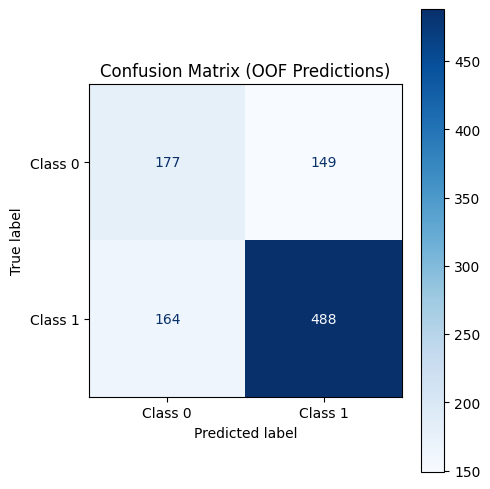

In [40]:
# =========================================================
# STEP 8 — Confusion Matrix
# Model 02: ELMo + Logistic Regression
# =========================================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))

ConfusionMatrixDisplay.from_predictions(
    oof_df["y_true"],
    oof_df["y_pred"],
    display_labels=["Class 0", "Class 1"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("Confusion Matrix (OOF Predictions)")

plt.tight_layout()
plt.show()